In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data=pd.read_csv("supermarket_sales.csv")

In [4]:
data

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1


In [5]:
df = pd.DataFrame(data, columns=['Date', 'Time', 'Total']) 
df.head() 

,Date,Time,Total
0,1/5/2019,13:08,548.9715
1,3/8/2019,10:29,80.2200
2,3/3/2019,13:23,340.5255
3,1/27/2019,20:33,489.0480
4,2/8/2019,10:37,634.3785


In [6]:

df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

df['Date'] = df['Date'].dt.day_name()

df

,Date,Time,Total
0,Saturday,13:08,548.9715
1,Friday,10:29,80.2200
2,Sunday,13:23,340.5255
3,Sunday,20:33,489.0480
4,Friday,10:37,634.3785
...,...,...,...
995,Tuesday,13:46,42.3675
996,Saturday,17:16,1022.4900
997,Saturday,13:22,33.4320
998,Friday,15:33,69.1110


In [7]:
df['Time']=pd.to_datetime(df['Time'],format='%H:%M')
df['Time']=df['Time'].dt.strftime('%I %p')
df

,Date,Time,Total
0,Saturday,01 PM,548.9715
1,Friday,10 AM,80.2200
2,Sunday,01 PM,340.5255
3,Sunday,08 PM,489.0480
4,Friday,10 AM,634.3785
...,...,...,...
995,Tuesday,01 PM,42.3675
996,Saturday,05 PM,1022.4900
997,Saturday,01 PM,33.4320
998,Friday,03 PM,69.1110


## Pivotement des données 

In [8]:
duplicates = df[df.duplicated(subset=['Date', 'Time'], keep=False)]
duplicates

,Date,Time,Total
0,Saturday,01 PM,548.9715
1,Friday,10 AM,80.2200
2,Sunday,01 PM,340.5255
3,Sunday,08 PM,489.0480
4,Friday,10 AM,634.3785
...,...,...,...
995,Tuesday,01 PM,42.3675
996,Saturday,05 PM,1022.4900
997,Saturday,01 PM,33.4320
998,Friday,03 PM,69.1110


In [9]:
df = df.groupby(['Date', 'Time'], as_index=False).agg({'Total': 'sum'})

In [10]:
df_pivot = df.pivot(index='Time', columns='Date', values='Total') 
df_pivot.head() 

Date,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
Time,,,,,,,
01 PM,6824.3070,3758.6325,5689.6350,5159.5530,2594.2245,3962.5320,6734.3430
02 PM,5166.2730,2004.3450,5341.8750,4676.1225,5474.0490,4953.1650,3212.5695
03 PM,3696.0630,5141.3460,3471.0165,2681.8575,4313.0850,7020.2055,4855.9350
04 PM,3092.3445,4690.9905,3813.5160,2241.2250,4327.1865,3831.4395,3229.6215
05 PM,1893.4125,3179.2635,5069.8095,4169.3400,4056.5910,2975.5320,3101.2695


In [11]:
print(df_pivot.head())  # Aperçu des données pivotées
print(df['Time'].unique())  # Vérifiez les heures disponibles


Date      Friday     Monday   Saturday     Sunday   Thursday    Tuesday  \
Time                                                                      
01 PM  6824.3070  3758.6325  5689.6350  5159.5530  2594.2245  3962.5320   
02 PM  5166.2730  2004.3450  5341.8750  4676.1225  5474.0490  4953.1650   
03 PM  3696.0630  5141.3460  3471.0165  2681.8575  4313.0850  7020.2055   
04 PM  3092.3445  4690.9905  3813.5160  2241.2250  4327.1865  3831.4395   
05 PM  1893.4125  3179.2635  5069.8095  4169.3400  4056.5910  2975.5320   

Date   Wednesday  
Time              
01 PM  6734.3430  
02 PM  3212.5695  
03 PM  4855.9350  
04 PM  3229.6215  
05 PM  3101.2695  
['01 PM' '02 PM' '03 PM' '04 PM' '05 PM' '06 PM' '07 PM' '08 PM' '10 AM'
 '11 AM' '12 PM']


## Création du graphique radar pour chaque jour 


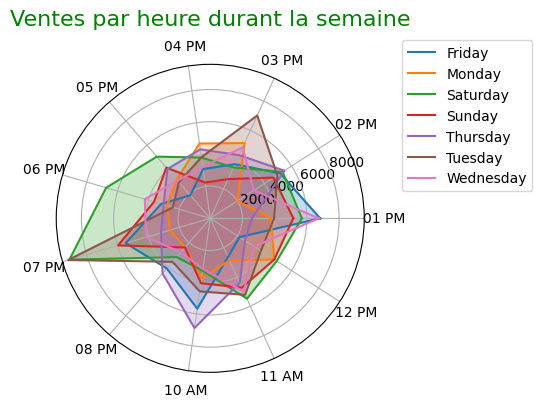

In [12]:
fig, ax = plt.subplots(figsize=(5, 4), subplot_kw=dict(polar=True)) 
for jour in df_pivot.columns:
    valeurs = df_pivot[jour].fillna(0).values  # Remplacer NaN par 0 si nécessaire
    angles = np.linspace(0, 2 * np.pi, len(df_pivot), endpoint=False).tolist()
    
    # Fermer le graphique
    valeurs = np.concatenate((valeurs, [valeurs[0]]))
    angles += angles[:1]
    
    # Tracer la courbe et remplir
    ax.plot(angles, valeurs, label=jour)
    ax.fill(angles, valeurs, alpha=0.25)

# Configurer les ticks (labels des heures)
ax.set_xticks(np.linspace(0, 2 * np.pi, len(df_pivot), endpoint=False))
ax.set_xticklabels(df_pivot.index)  # Utiliser les heures comme labels

# Ajouter le titre et la légende
plt.title('Ventes par heure durant la semaine', size=16, color='green', y=1.1)
plt.legend(loc='best', bbox_to_anchor=(1.1, 1.1))
plt.show()